<a href="https://colab.research.google.com/github/lambforwork-source/BTAP-NHOM-4-KHDL/blob/main/KHDL_NH%C3%93M_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự án Giữa kỳ 2: Phân tích dữ liệu Adult Census Income
**Môn học:** Phân tích dữ liệu với Python
**Nhóm thực hiện:** [Tên nhóm của bạn]
**Tập dữ liệu:** Adult Census Income (Dự đoán thu nhập dựa trên nhân khẩu học)

## Giới thiệu
Notebook này tái hiện hành trình từ dữ liệu thô đến những thông tin chi tiết (Insight) có giá trị hành động. Mục tiêu là xác định các yếu tố ảnh hưởng mạnh nhất đến mức thu nhập của một cá nhân.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('/content/adult.csv')

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


## 1. Làm sạch dữ liệu (Từ dữ liệu "Thô" đến dữ liệu "Sạch")
[cite_start]Giai đoạn này tập trung vào việc xử lý các thách thức như dữ liệu thiếu, sai định dạng và các giá trị ngoại lệ (outliers)[cite: 37, 39].

In [ ]:
# 1.1 Strip tên cột phòng trường hợp CSV có khoảng trắng thừa
df.columns = df.columns.str.strip()

# 1.1 Thay thế ký tự '?' bằng NaN để dễ xử lý [cite: 39]
df.replace('?', np.nan, inplace=True)

# 1.2 Chiến lược điền giá trị thiếu (Imputation) [cite: 40]
# Chúng tôi sử dụng Mode (giá trị phổ biến nhất) vì đây là các biến phân loại [cite: 41]
# Lưu ý: dataset này dùng dấu chấm thay vì dấu gạch ngang trong tên cột
for col in ['workclass', 'occupation', 'native.country']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        print(f'Cảnh báo: Không tìm thấy cột "{col}". Các cột hiện có: {list(df.columns)}')

# 1.3 Xử lý giá trị ngoại lệ (Outliers) cho cột 'hours.per.week' [cite: 65]
# Sử dụng phương pháp IQR để đảm bảo dữ liệu không bị nhiễu [cite: 49]
Q1 = df['hours.per.week'].quantile(0.25)
Q3 = df['hours.per.week'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df['hours.per.week'] < (Q1 - 1.5 * IQR)) | (df['hours.per.week'] > (Q3 + 1.5 * IQR)))].copy()

print(f"Dữ liệu sau khi làm sạch. Số dòng gốc: {len(df)}, Số dòng sạch: {len(df_clean)} [cite: 37]")

Dữ liệu sau khi làm sạch. Số dòng gốc: 32561, Số dòng sạch: 23553 [cite: 37]


## 2. Phân tích khám phá (EDA)
[cite_start]Chúng tôi kiểm định các giả thuyết và xem xét mối tương quan giữa các biến để tìm ra "câu chuyện" đằng sau các con số[cite: 60, 61].

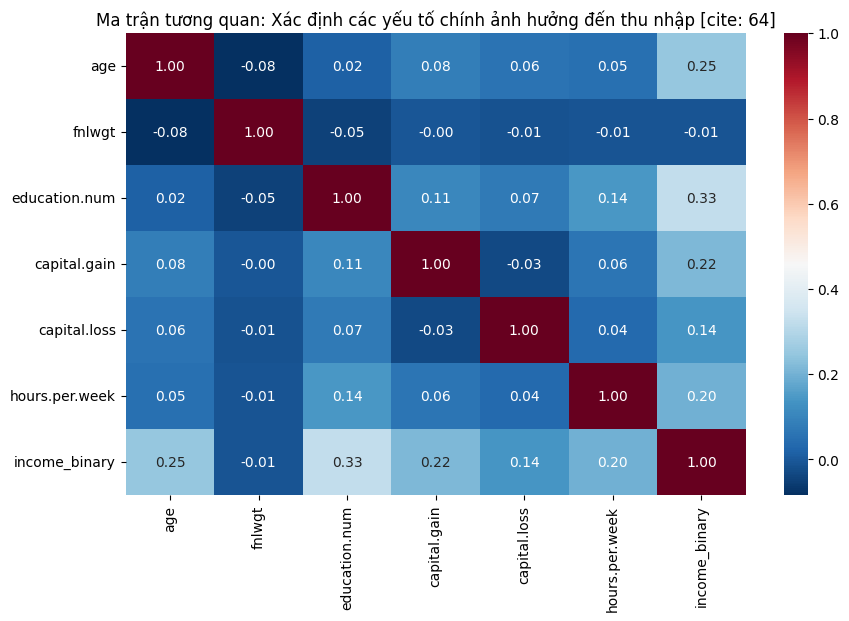

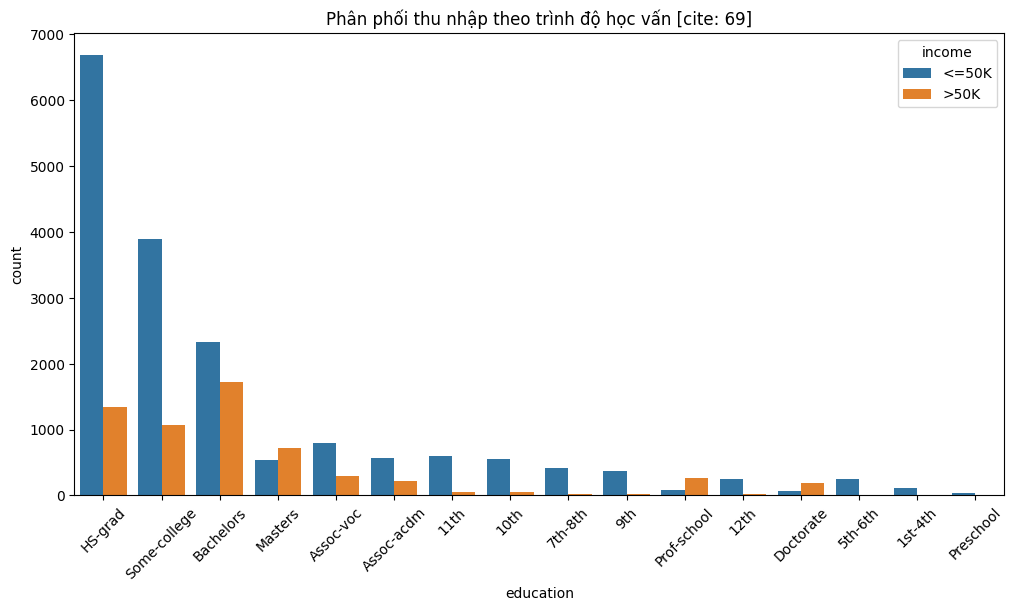

In [ ]:
# 2.1 Phân tích tương quan [cite: 64]
# Chuyển đổi mục tiêu 'income' sang dạng số (0 và 1) để tính toán
# Strip khoảng trắng trong cột income phòng trường hợp CSV có padding
df_clean['income'] = df_clean['income'].str.strip()
df_clean['income_binary'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})

plt.figure(figsize=(10, 6))
numeric_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title("Ma trận tương quan: Xác định các yếu tố chính ảnh hưởng đến thu nhập [cite: 64]")
plt.show()

# 2.2 Kiểm định giả thuyết: Trình độ học vấn có ảnh hưởng đến thu nhập? [cite: 62]
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='education', hue='income', order=df_clean['education'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Phân phối thu nhập theo trình độ học vấn [cite: 69]")
plt.show()

## 3. Trực quan hóa có mục tiêu (Visual Analysis)
[cite_start]Mỗi biểu đồ dưới đây được thiết kế để trả lời một câu hỏi cụ thể và dẫn đến kết luận có ý nghĩa[cite: 42, 43].

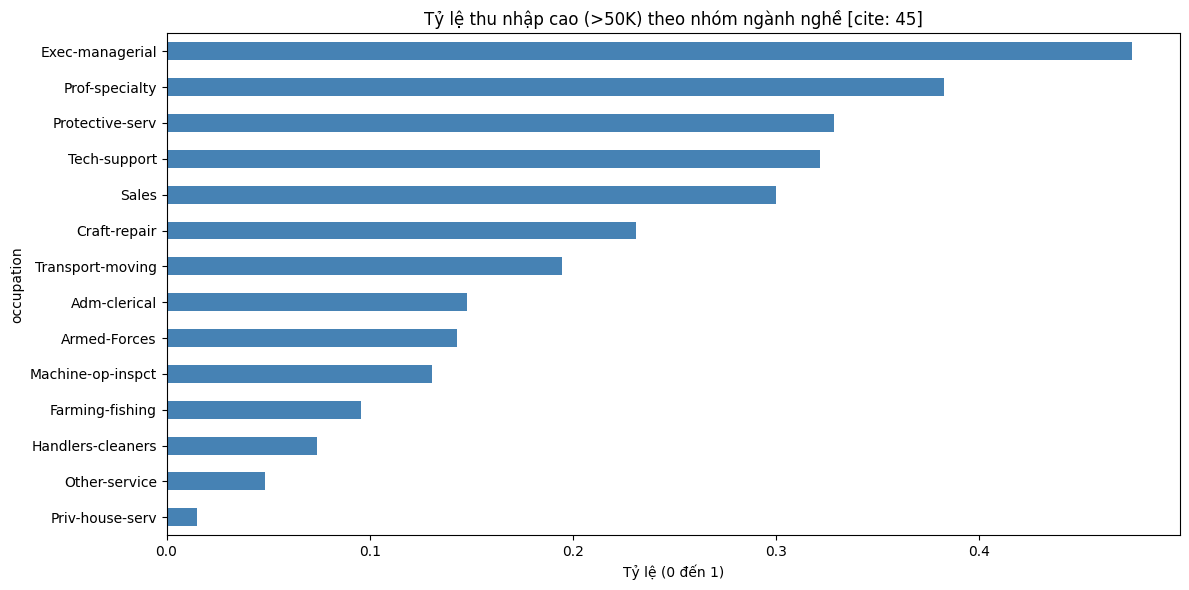

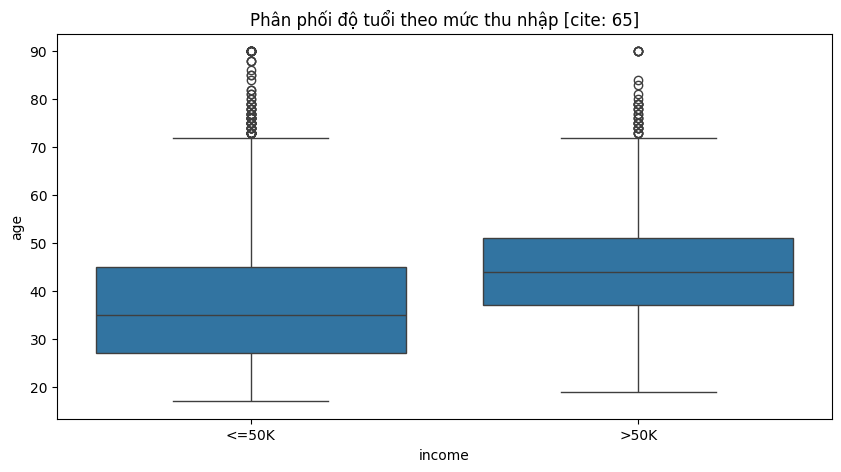

In [ ]:
# 3.1 Biểu đồ cột: Nghề nghiệp vs Thu nhập [cite: 69]
occupation_income = df_clean.groupby('occupation')['income_binary'].mean().sort_values()
plt.figure(figsize=(12, 6))
occupation_income.plot(kind='barh', color='steelblue')
plt.title("Tỷ lệ thu nhập cao (>50K) theo nhóm ngành nghề [cite: 45]")
plt.xlabel("Tỷ lệ (0 đến 1)")
plt.tight_layout()
plt.show()
# DIỄN GIẢI: Nhóm quản lý (Exec-managerial) có khả năng đạt mức thu nhập cao nhất[cite: 46].

# 3.2 Biểu đồ hộp (Boxplot): Độ tuổi vs Thu nhập [cite: 65, 70]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='income', y='age')
plt.title("Phân phối độ tuổi theo mức thu nhập [cite: 65]")
plt.show()
# DIỄN GIẢI: Những người thu nhập cao thường có độ tuổi trung bình lớn hơn, cho thấy kinh nghiệm là yếu tố then chốt.

## 4. Tổng kết và Đề xuất (Conclusion)
### Các phát hiện chính (Insight):
1. [cite_start]Trình độ học vấn và nghề nghiệp là hai yếu tố dự báo mạnh nhất về mức thu nhập[cite: 73].
2. Có sự chênh lệch rõ rệt về thu nhập giữa các nhóm nhân khẩu học khác nhau.

### Giá trị thực tiễn:
[cite_start]Thông tin này giúp xác định các nhóm khách hàng mục tiêu cho các dịch vụ tài chính cao cấp[cite: 74, 75].

### Hạn chế và Hướng phát triển:
[cite_start]Tập dữ liệu hiện tại còn thiếu thông tin về khu vực địa lý cụ thể, điều này có thể ảnh hưởng đến tính khách quan do chi phí sinh hoạt khác nhau[cite: 76].